# Clase 8 — Estadística aplicada con Python

**Python y Políticas Públicas**

---

## Contenidos
1. Estadística descriptiva con pandas y scipy
2. Correlaciones e interpretación
3. Regresión lineal simple con statsmodels (OLS)
4. Regresión lineal múltiple
5. Tablas de resultados para un policy brief
6. Ejercicios

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

%matplotlib inline
pd.set_option('display.float_format', '{:.4f}'.format)

# Dataset provincial (mismo que clases anteriores, expandido)
np.random.seed(42)
n = 24
provincias = [
    "CABA", "Buenos Aires", "Córdoba", "Santa Fe", "Mendoza",
    "Tucumán", "Salta", "Entre Ríos", "Chaco", "Misiones",
    "Corrientes", "Santiago del Estero", "Jujuy", "Río Negro", "Neuquén",
    "Formosa", "San Juan", "San Luis", "Catamarca", "La Rioja",
    "La Pampa", "Chubut", "Santa Cruz", "Tierra del Fuego"
]

gasto_educ = np.random.uniform(12, 28, n)
gasto_salud = np.random.uniform(8, 20, n)

df = pd.DataFrame({
    'provincia': provincias,
    'pobreza': np.random.uniform(15, 58, n).round(1),
    'desempleo': np.random.uniform(3, 15, n).round(1),
    'pbi_pc': np.random.uniform(4, 18, n).round(1),
    'gasto_educacion': gasto_educ.round(1),
    'gasto_salud': gasto_salud.round(1),
    'anios_escolaridad': np.random.uniform(7, 13, n).round(1),
    'mortalidad_infantil': np.random.uniform(5, 25, n).round(1),
    'cobertura_agua': np.random.uniform(65, 99, n).round(1),
})

# Introducir correlaciones realistas
df['pobreza'] = (65 - df['pbi_pc'] * 2.5 - df['anios_escolaridad'] * 1.5
                 + np.random.normal(0, 4, n)).clip(10, 65).round(1)
df['mortalidad_infantil'] = (30 - df['cobertura_agua'] * 0.2 + df['pobreza'] * 0.2
                              + np.random.normal(0, 2, n)).clip(3, 30).round(1)

print(f"Dataset: {df.shape}")
df.head()

Dataset: (24, 9)


,provincia,pobreza,desempleo,pbi_pc,gasto_educacion,gasto_salud,anios_escolaridad,mortalidad_infantil,cobertura_agua
0,CABA,20.1000,3.1000,11.3000,18.0000,13.5000,11.8000,20.2000,66.4000
1,Buenos Aires,24.5000,12.8000,10.0000,27.2000,17.4000,12.4000,16.4000,85.1000
2,Córdoba,35.7000,11.5000,4.4000,23.7000,10.4000,8.9000,17.8000,88.0000
3,Santa Fe,34.4000,11.7000,5.5000,21.6000,14.2000,7.7000,22.1000,65.6000
4,Mendoza,43.5000,12.3000,4.4000,14.5000,15.1000,8.4000,22.1000,82.4000


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Paleta de identidad del curso ---
C = ['#2A6496', '#E07B3F', '#3D9970', '#8E5EA2', '#C0A830', '#637A8A']

mpl.rcParams.update({
    'figure.figsize'       : (10, 5),
    'font.size'            : 11,
    'axes.titlesize'       : 12,
    'axes.titleweight'     : 'normal',
    'axes.spines.top'      : False,
    'axes.spines.right'    : False,
    'legend.frameon'       : False,
    'axes.prop_cycle'      : mpl.cycler(color=C),
    'figure.dpi'           : 110,
})

def tit(ax, t, **kw):
    """Título sin negrita, alineado a la izquierda."""
    ax.set_title(t, loc='left', fontweight='normal', **kw)


---
## 1. Estadística descriptiva

Antes de cualquier modelo, siempre hay que conocer bien los datos.

In [3]:
# Estadísticas descriptivas completas
desc = df.select_dtypes(include='number').describe().T
desc['cv'] = (desc['std'] / desc['mean'] * 100).round(1)  # coeficiente de variación
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,cv
pobreza,24.0000,24.9500,11.3100,10.0000,13.1800,24.0500,34.7200,43.5000,45.3000
desempleo,24.0000,9.1300,3.4000,3.1000,6.8500,10.1000,11.8800,13.6000,37.3000
pbi_pc,24.0000,10.6100,4.2600,4.4000,7.0500,10.5500,14.7800,17.0000,40.2000
gasto_educacion,24.0000,19.0400,4.6600,12.3000,14.9000,17.9500,22.1800,27.5000,24.5000
gasto_salud,24.0000,13.5000,3.5800,8.4000,10.3000,13.7000,16.0500,19.6000,26.5000
anios_escolaridad,24.0000,9.9800,1.8100,7.0000,8.7300,9.5500,11.8200,12.8000,18.1000
mortalidad_infantil,24.0000,18.8400,3.3300,12.8000,16.5500,18.6500,21.6500,24.5000,17.7000
cobertura_agua,24.0000,81.0700,10.3000,65.6000,72.2500,82.7000,88.1200,96.8000,12.7000


In [4]:
# Percentiles adicionales
for var in ['pobreza', 'pbi_pc', 'mortalidad_infantil']:
    q = df[var].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
    print(f"{var}: p10={q[0.1]:.1f}, p25={q[0.25]:.1f}, mediana={q[0.5]:.1f}, p75={q[0.75]:.1f}, p90={q[0.9]:.1f}")

pobreza: p10=10.4, p25=13.2, mediana=24.1, p75=34.7, p90=40.0
pbi_pc: p10=5.2, p25=7.0, mediana=10.6, p75=14.8, p90=16.4
mortalidad_infantil: p10=14.5, p25=16.6, mediana=18.6, p75=21.6, p90=23.4


In [5]:
# Tests estadísticos básicos con scipy

# Test de normalidad (Shapiro-Wilk)
for var in ['pobreza', 'pbi_pc']:
    stat, p = stats.shapiro(df[var])
    interpretacion = "no rechaza normalidad" if p > 0.05 else "rechaza normalidad"
    print(f"Shapiro-Wilk ({var}): W={stat:.3f}, p={p:.3f} → {interpretacion}")

Shapiro-Wilk (pobreza): W=0.926, p=0.081 → no rechaza normalidad
Shapiro-Wilk (pbi_pc): W=0.928, p=0.087 → no rechaza normalidad


---
## 2. Correlaciones e interpretación

In [6]:
# Matriz de correlación de Pearson
corr_vars = ['pobreza', 'desempleo', 'pbi_pc', 'gasto_educacion', 'anios_escolaridad', 'mortalidad_infantil']
corr = df[corr_vars].corr()
corr.round(3)

,pobreza,desempleo,pbi_pc,gasto_educacion,anios_escolaridad,mortalidad_infantil
pobreza,1.0000,-0.0570,-0.9320,-0.1340,-0.4580,0.5630
desempleo,-0.0570,1.0000,0.0150,-0.0370,0.0120,-0.4450
pbi_pc,-0.9320,0.0150,1.0000,0.1160,0.2750,-0.4640
gasto_educacion,-0.1340,-0.0370,0.1160,1.0000,-0.0260,0.2640
anios_escolaridad,-0.4580,0.0120,0.2750,-0.0260,1.0000,-0.4630
mortalidad_infantil,0.5630,-0.4450,-0.4640,0.2640,-0.4630,1.0000


In [7]:
# Correlación con test de significancia
print(f"{'Variable':<25} {'r':>6} {'p-valor':>10} {'Significativa':>15}")
print("-" * 60)

for var in corr_vars:
    if var == 'pobreza':
        continue
    r, p = stats.pearsonr(df['pobreza'].dropna(), df[var].dropna())
    sig = "✓ (p<0.05)" if p < 0.05 else "✗"
    print(f"{var:<25} {r:>6.3f} {p:>10.3f} {sig:>15}")

Variable                       r    p-valor   Significativa
------------------------------------------------------------
desempleo                 -0.057      0.791               ✗
pbi_pc                    -0.932      0.000      ✓ (p<0.05)
gasto_educacion           -0.134      0.533               ✗
anios_escolaridad         -0.458      0.024      ✓ (p<0.05)
mortalidad_infantil        0.563      0.004      ✓ (p<0.05)


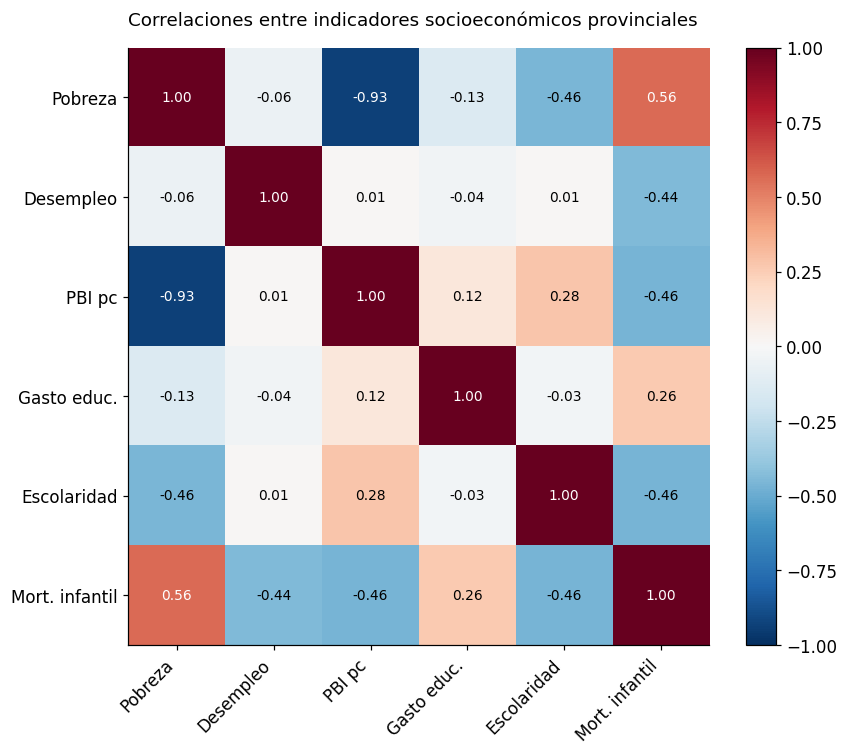

In [8]:
# Heatmap de correlaciones
fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)

etiquetas = ['Pobreza', 'Desempleo', 'PBI pc', 'Gasto educ.', 'Escolaridad', 'Mort. infantil']
ax.set_xticks(range(len(corr_vars)))
ax.set_yticks(range(len(corr_vars)))
ax.set_xticklabels(etiquetas, rotation=45, ha='right')
ax.set_yticklabels(etiquetas)

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        color = 'white' if abs(corr.values[i, j]) > 0.5 else 'black'
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha='center', va='center', fontsize=9, color=color)

ax.set_title("Correlaciones entre indicadores socioeconómicos provinciales", fontsize=12, pad=15, loc='left')
plt.tight_layout()
plt.show()


---
## 3. Regresión lineal simple (OLS)

La regresión OLS (Mínimos Cuadrados Ordinarios) estima la relación lineal entre una variable dependiente (Y) y una o más variables independientes (X).

**Interpretación**: el coeficiente β₁ indica cuánto cambia Y en promedio cuando X aumenta en 1 unidad, manteniendo lo demás constante.

In [9]:
# ¿Cómo se relaciona el PBI per cápita con la tasa de pobreza?
modelo_simple = smf.ols('pobreza ~ pbi_pc', data=df).fit()
print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                pobreza   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     145.7
Date:                Tue, 19 May 2026   Prob (F-statistic):           3.56e-11
Time:                        14:03:53   Log-Likelihood:                -67.383
No. Observations:                  24   AIC:                             138.8
Df Residuals:                      22   BIC:                             141.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     51.1819      2.335     21.917      0.0

In [10]:
# Extraer los resultados clave
print("=" * 50)
print("RESULTADOS PRINCIPALES")
print("=" * 50)
print(f"Intercepto (α):   {modelo_simple.params['Intercept']:.2f}")
print(f"Coeficiente PBI:  {modelo_simple.params['pbi_pc']:.2f}")
print(f"  → Por cada 1.000$ más de PBI per cápita, la tasa de pobreza")
print(f"    varía en {modelo_simple.params['pbi_pc']:.2f} puntos porcentuales")
print(f"p-valor (PBI):    {modelo_simple.pvalues['pbi_pc']:.4f}")
print(f"R² ajustado:      {modelo_simple.rsquared_adj:.3f}")
print(f"  → El modelo explica el {modelo_simple.rsquared_adj*100:.1f}% de la varianza en pobreza")

RESULTADOS PRINCIPALES
Intercepto (α):   51.18
Coeficiente PBI:  -2.47
  → Por cada 1.000$ más de PBI per cápita, la tasa de pobreza
    varía en -2.47 puntos porcentuales
p-valor (PBI):    0.0000
R² ajustado:      0.863
  → El modelo explica el 86.3% de la varianza en pobreza


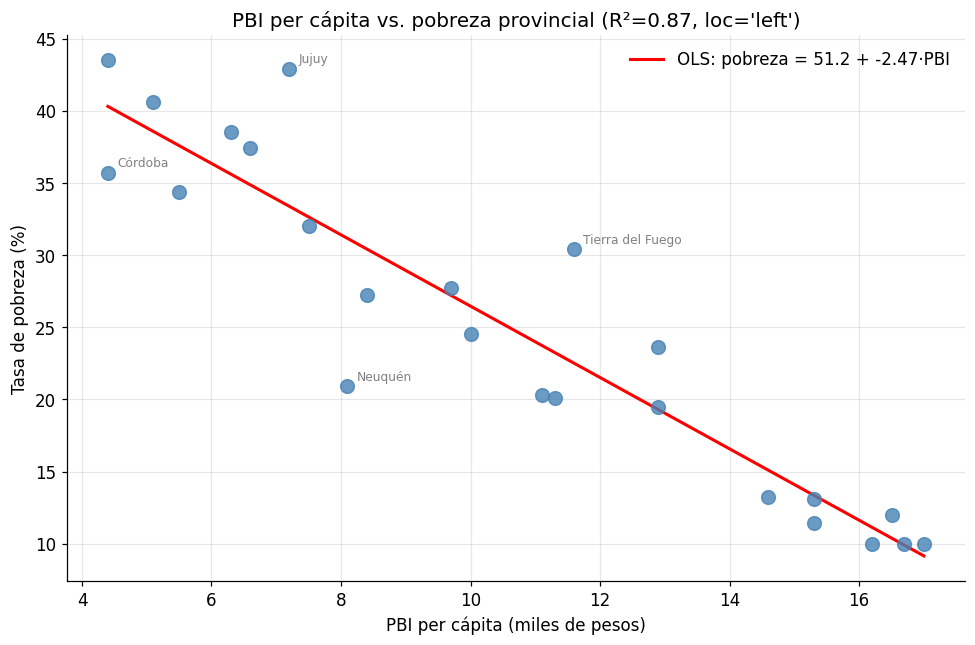

In [11]:
# Visualizar la regresión
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['pbi_pc'], df['pobreza'], alpha=0.8, color='steelblue', s=80, zorder=3)

# Línea de regresión
x_range = np.linspace(df['pbi_pc'].min(), df['pbi_pc'].max(), 100)
y_pred = modelo_simple.params['Intercept'] + modelo_simple.params['pbi_pc'] * x_range
ax.plot(x_range, y_pred, color='red', linewidth=2, label=f'OLS: pobreza = {modelo_simple.params["Intercept"]:.1f} + {modelo_simple.params["pbi_pc"]:.2f}·PBI')

# Etiquetar outliers (residuos grandes)
df['residuo'] = modelo_simple.resid
outliers = df[df['residuo'].abs() > df['residuo'].abs().quantile(0.85)]
for _, row in outliers.iterrows():
    ax.annotate(row['provincia'], (row['pbi_pc'], row['pobreza']),
                textcoords='offset points', xytext=(6, 4), fontsize=8, color='gray')

ax.set_title(f"PBI per cápita vs. pobreza provincial (R²={modelo_simple.rsquared:.2f}, loc='left')",
             fontsize=13)
ax.set_xlabel("PBI per cápita (miles de pesos)")
ax.set_ylabel("Tasa de pobreza (%)")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## 4. Regresión lineal múltiple

In [12]:
# Modelo con múltiples predictores
modelo_multiple = smf.ols(
    'pobreza ~ pbi_pc + anios_escolaridad + gasto_educacion + desempleo',
    data=df
).fit()

print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                pobreza   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     51.84
Date:                Tue, 19 May 2026   Prob (F-statistic):           5.81e-10
Time:                        14:03:53   Log-Likelihood:                -62.020
No. Observations:                  24   AIC:                             134.0
Df Residuals:                      19   BIC:                             139.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            66.2765      5.68

In [13]:
# Comparar modelos
print(f"{'Modelo':<40} {'R² ajustado':>12} {'AIC':>10}")
print("-" * 65)
print(f"{'Simple (solo PBI pc)':<40} {modelo_simple.rsquared_adj:>12.3f} {modelo_simple.aic:>10.1f}")
print(f"{'Múltiple (PBI + educ + desempleo)':<40} {modelo_multiple.rsquared_adj:>12.3f} {modelo_multiple.aic:>10.1f}")

Modelo                                    R² ajustado        AIC
-----------------------------------------------------------------
Simple (solo PBI pc)                            0.863      138.8
Múltiple (PBI + educ + desempleo)               0.898      134.0


---
## 5. Tablas de resultados para un policy brief

En un policy brief necesitamos presentar los resultados de forma clara y concisa, sin toda la salida técnica de `summary()`.

In [14]:
def tabla_regresion(modelo, nombre_vars=None):
    """Genera una tabla de regresión limpia para un policy brief."""
    params = modelo.params
    pvalues = modelo.pvalues
    conf = modelo.conf_int()
    
    rows = []
    for var in params.index:
        p = pvalues[var]
        sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        rows.append({
            'Variable': nombre_vars.get(var, var) if nombre_vars else var,
            'Coeficiente': f"{params[var]:.3f}{sig}",
            'IC 95%': f"[{conf.loc[var, 0]:.3f}, {conf.loc[var, 1]:.3f}]",
            'p-valor': f"{p:.3f}",
        })
    
    tabla = pd.DataFrame(rows)
    print(tabla.to_string(index=False))
    print(f"\nObservaciones: {int(modelo.nobs)}")
    print(f"R² ajustado: {modelo.rsquared_adj:.3f}")
    print("Significancia: *** p<0.01, ** p<0.05, * p<0.1")
    return tabla

nombres = {
    'Intercept': 'Constante',
    'pbi_pc': 'PBI per cápita (miles $)',
    'anios_escolaridad': 'Años de escolaridad promedio',
    'gasto_educacion': 'Gasto en educación (% presupuesto)',
    'desempleo': 'Tasa de desempleo (%)',
}

print("Tabla 1. Determinantes de la tasa de pobreza provincial")
print("Variable dependiente: Tasa de pobreza (%)")
print("="*65)
tabla_regresion(modelo_multiple, nombres)

Tabla 1. Determinantes de la tasa de pobreza provincial
Variable dependiente: Tasa de pobreza (%)
                          Variable Coeficiente           IC 95% p-valor
                         Constante   66.276*** [54.376, 78.177]   0.000
          PBI per cápita (miles $)   -2.297*** [-2.685, -1.910]   0.000
      Años de escolaridad promedio   -1.378*** [-2.285, -0.471]   0.005
Gasto en educación (% presupuesto)      -0.099  [-0.440, 0.241]   0.550
             Tasa de desempleo (%)      -0.144  [-0.606, 0.319]   0.523

Observaciones: 24
R² ajustado: 0.898
Significancia: *** p<0.01, ** p<0.05, * p<0.1


,Variable,Coeficiente,IC 95%,p-valor
0,Constante,66.276***,"[54.376, 78.177]",0.000
1,PBI per cápita (miles $),-2.297***,"[-2.685, -1.910]",0.000
2,Años de escolaridad promedio,-1.378***,"[-2.285, -0.471]",0.005
3,Gasto en educación (% presupuesto),-0.099,"[-0.440, 0.241]",0.550
4,Tasa de desempleo (%),-0.144,"[-0.606, 0.319]",0.523


---
## 6. Ejercicios

### Ejercicio 1
Estimá un modelo OLS simple para explicar la `mortalidad_infantil` en función de la `cobertura_agua`. Interpretá el coeficiente y calculá el R².

In [15]:
# Tu solución aquí


### Ejercicio 2
Construí un modelo múltiple para explicar la `mortalidad_infantil` usando al menos 3 predictores. Comparalo con el modelo simple del ejercicio anterior usando R² ajustado.

In [16]:
# Tu solución aquí


### Ejercicio 3
Usando la función `tabla_regresion()` definida en esta clase, generá una tabla de resultados lista para incluir en un policy brief para el modelo múltiple del ejercicio 2.

In [17]:
# Tu solución aquí
